## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 2. Load and Preprocess the Dataset

Fashion MNIST contains 70,000 grayscale images (28x28 pixels) across 10 clothing categories:
`T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot`

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [3]:
# Preprocess: normalize pixel values to [0, 1] and reshape to add channel dimension
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Add channel dimension (28, 28) -> (28, 28, 1) since images are grayscale
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("x_train_cnn shape:", x_train_cnn.shape)
print("x_test_cnn shape:", x_test_cnn.shape)
print("y_train_cat shape:", y_train_cat.shape)


x_train_cnn shape: (60000, 28, 28, 1)
x_test_cnn shape: (10000, 28, 28, 1)
y_train_cat shape: (60000, 10)


## 3. Display Sample Images

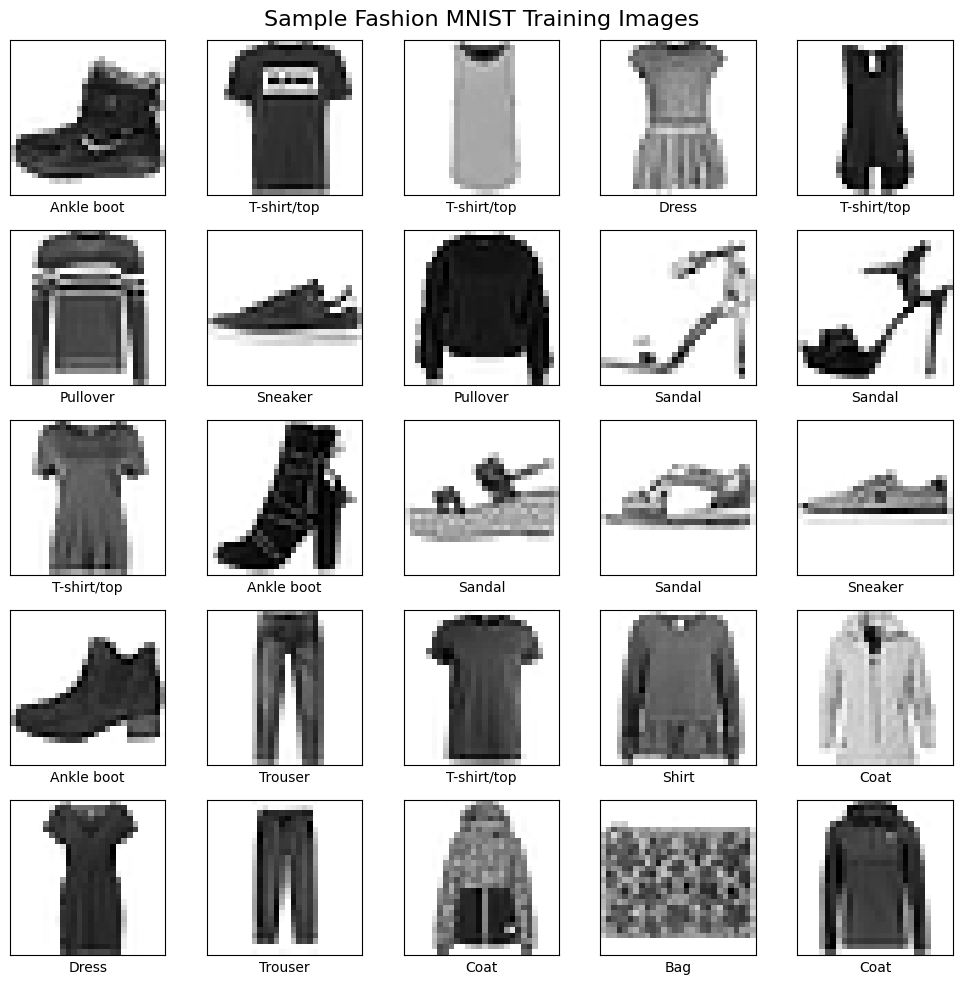

In [4]:
# Display a grid of sample training images with their labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.suptitle("Sample Fashion MNIST Training Images", fontsize=16)
plt.tight_layout()
plt.show()


## 4. Build the CNN Model

In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

## 5. Train the CNN

In [6]:
history = model.fit(
    x_train_cnn, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 290s 664ms/step - accuracy: 0.8211 - loss: 0.5117 - val_accuracy: 0.7945 - val_loss: 0.6338
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 276s 654ms/step - accuracy: 0.8833 - loss: 0.3255 - val_accuracy: 0.9023 - val_loss: 0.2755
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 335s 685ms/step - accuracy: 0.9017 - loss: 0.2792 - val_accuracy: 0.9158 - val_loss: 0.2306
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 313s 664ms/step - accuracy: 0.9097 - loss: 0.2509 - val_accuracy: 0.9175 - val_loss: 0.2215
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 317s 652ms/step - accuracy: 0.9177 - loss: 0.2308 - val_accuracy: 0.9170 - val_loss: 0.2259
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 330s 672ms/step - accuracy: 0.9207 - loss: 0.2174 - val_accuracy: 0.9277 - val_loss: 0.1961
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 291s 688ms/step - accuracy: 0.9247 - loss: 0.2076 - val_accuracy: 0.9220 - val_loss: 0.2067
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 316s 674ms/step - accuracy: 0.9285 -

## 6. Evaluate the Model on the Test Dataset

In [7]:
test_loss, test_accuracy = model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Test Loss: 0.2078
Test Accuracy: 0.9297 (92.97%)


## 7. Plot Training and Validation Accuracy/Loss Curves

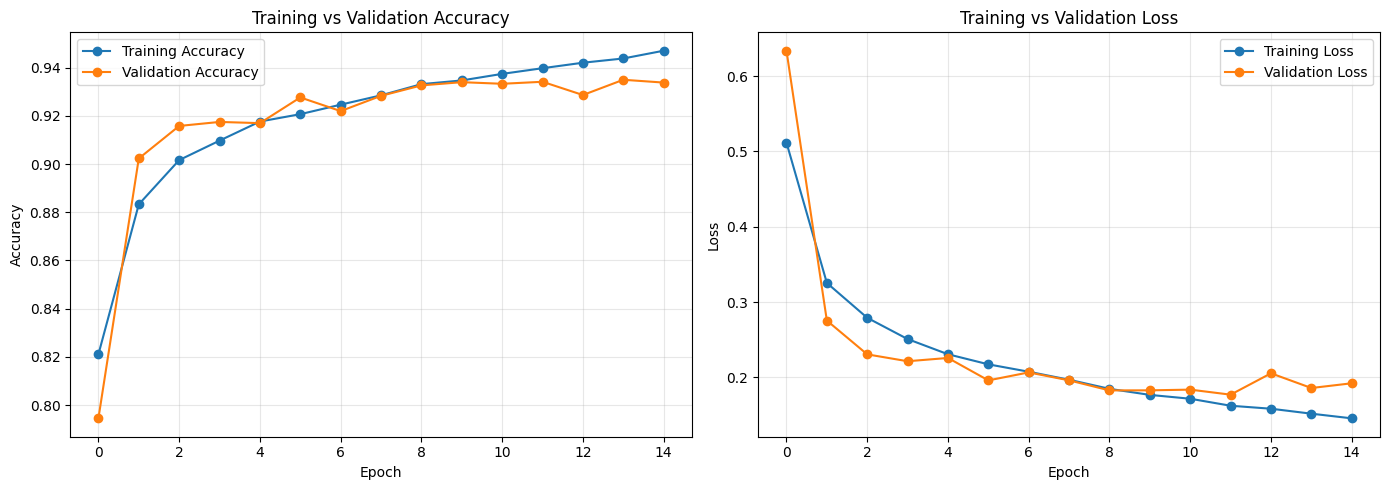

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Predict Classes and Compare Predicted vs Actual Labels

In [9]:
# Get predictions for the full test set
y_pred_probs = model.predict(x_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predicted labels (first 20):", y_pred[:20])
print("Actual labels    (first 20):", y_test[:20])


Predicted labels (first 20): [9 2 1 1 6 1 4 6 5 7 4 5 5 3 4 1 2 6 8 0]
Actual labels    (first 20): [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0]


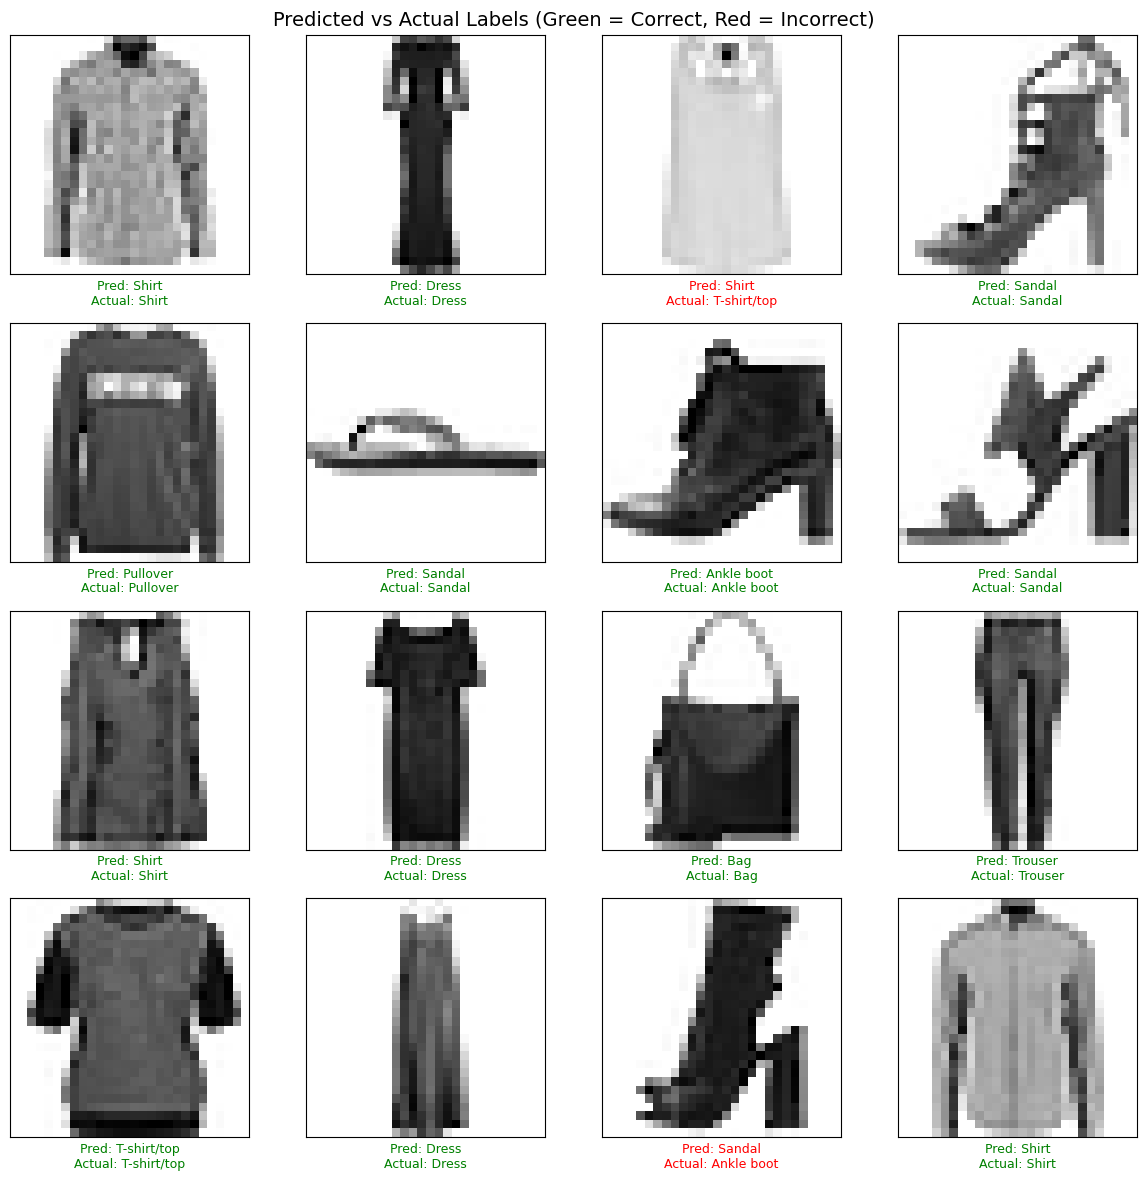

In [10]:
# Display sample test images with predicted vs actual labels
plt.figure(figsize=(12, 12))
num_samples = 16
sample_indices = np.random.choice(len(x_test), num_samples, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(4, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[idx], cmap=plt.cm.binary)
    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_test[idx]]
    color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    plt.xlabel(f"Pred: {pred_label}\nActual: {true_label}", color=color, fontsize=9)

plt.suptitle("Predicted vs Actual Labels (Green = Correct, Red = Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()


## 9. Confusion Matrix

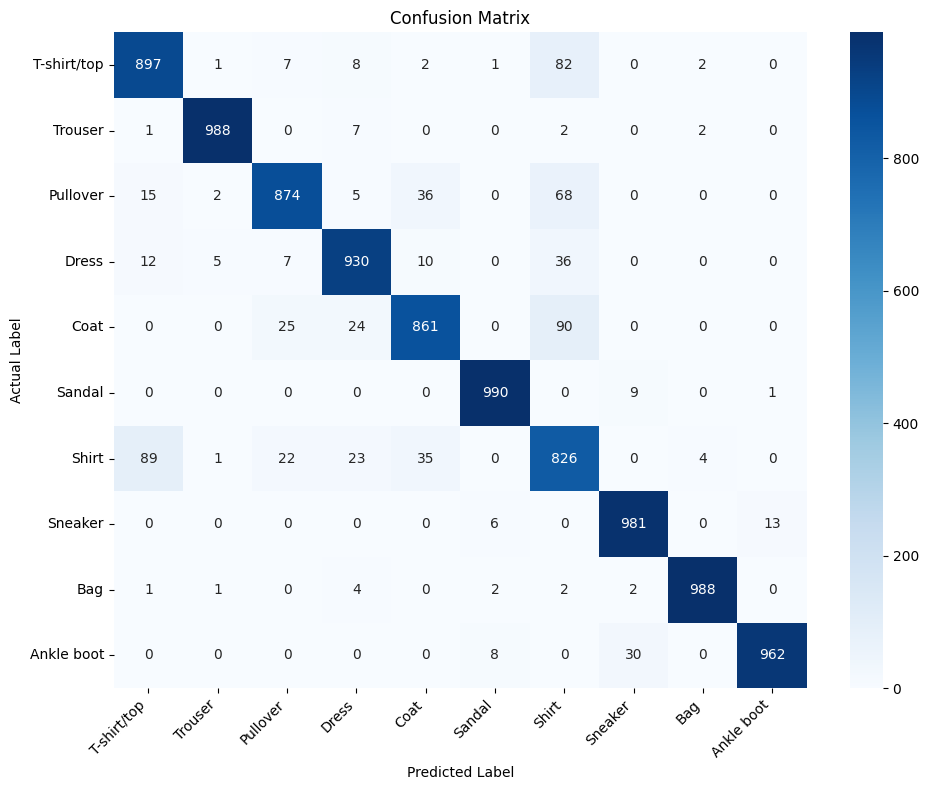


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.90      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.93      0.87      0.90      1000
       Dress       0.93      0.93      0.93      1000
        Coat       0.91      0.86      0.89      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.75      0.83      0.78      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


## 10. Show 10 Correctly and 10 Incorrectly Classified Images

In [12]:
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

print(f"Total correctly classified: {len(correct_indices)}")
print(f"Total incorrectly classified: {len(incorrect_indices)}")

np.random.shuffle(correct_indices)
np.random.shuffle(incorrect_indices)

correct_sample = correct_indices[:10]
incorrect_sample = incorrect_indices[:10]


Total correctly classified: 9297
Total incorrectly classified: 703


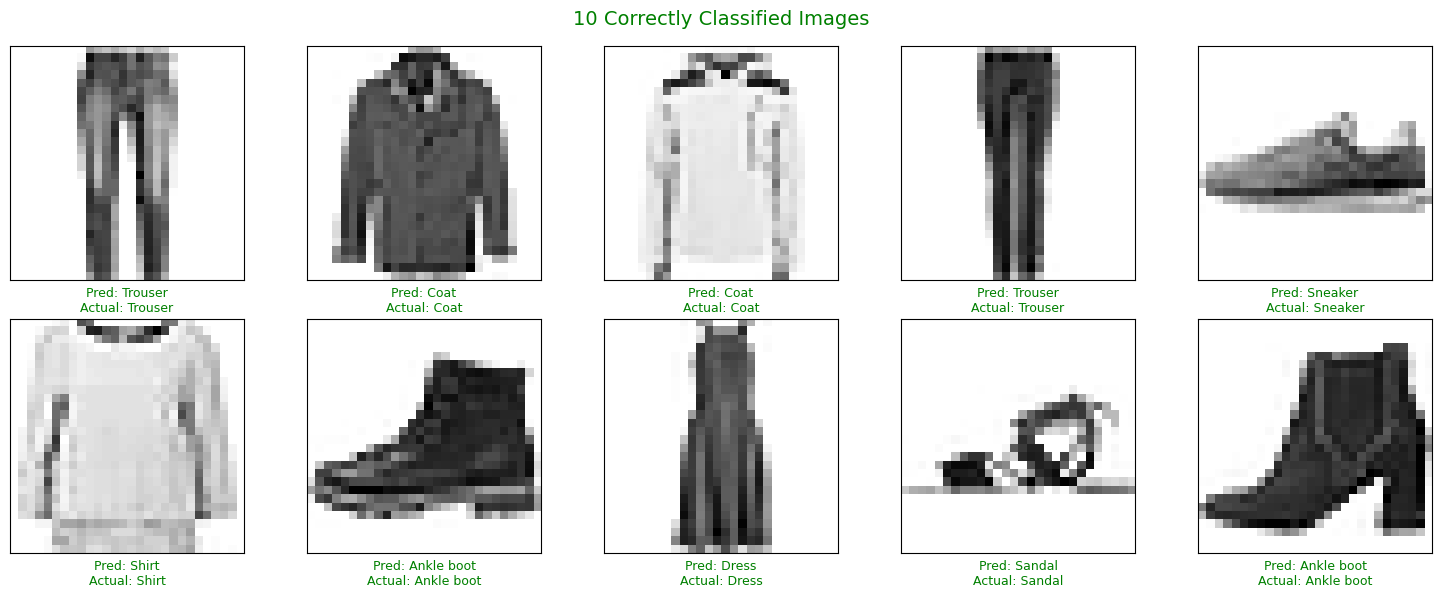

In [13]:
# 10 correctly classified images
plt.figure(figsize=(15, 6))
for i, idx in enumerate(correct_sample):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[idx], cmap=plt.cm.binary)
    plt.xlabel(f"Pred: {class_names[y_pred[idx]]}\nActual: {class_names[y_test[idx]]}",
               color='green', fontsize=9)
plt.suptitle("10 Correctly Classified Images", fontsize=14, color='green')
plt.tight_layout()
plt.show()


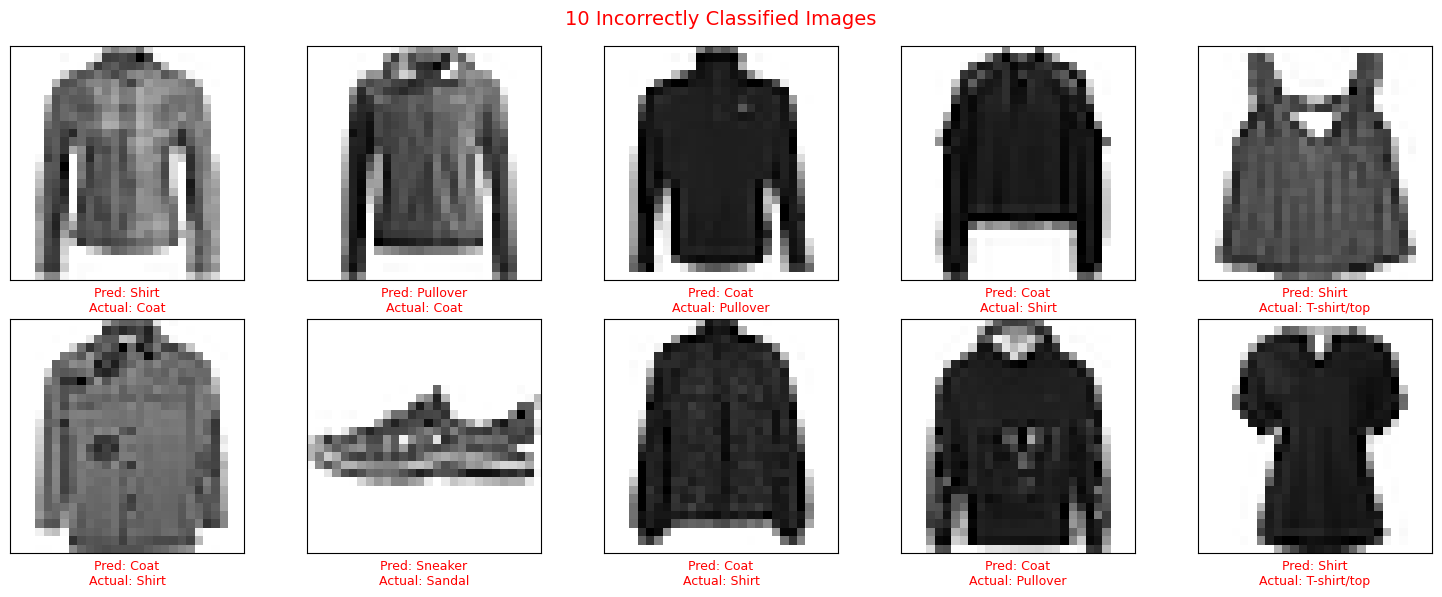

In [14]:
# 10 incorrectly classified images
plt.figure(figsize=(15, 6))
for i, idx in enumerate(incorrect_sample):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[idx], cmap=plt.cm.binary)
    plt.xlabel(f"Pred: {class_names[y_pred[idx]]}\nActual: {class_names[y_test[idx]]}",
               color='red', fontsize=9)
plt.suptitle("10 Incorrectly Classified Images", fontsize=14, color='red')
plt.tight_layout()
plt.show()
